In [190]:
import os
import pandas as pd
import gc
import seaborn as sns
import numpy as np
import scipy 
from lxml import etree as ET
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.max_open_warning': 0})

In [2]:
def parse_xml(path : str) -> pd.DataFrame:

    '''
    input:
    
    path : str --- path to xml file to parse

    output:

    data : pd.Dataframe --- pandas DataFrame with parsed XML file

    '''

    data = pd.read_xml(path)
    tree = ET.parse(path)
    lfsamples = tree.getroot()
    res = []
    for lfsampledescriptor in lfsamples:
        features = []
        for lfstagedescriptor in lfsampledescriptor:
            strong = []
            elem = lfstagedescriptor.attrib
            for lfweakdescriptor in lfstagedescriptor:
                strong.append((elem,{'attributes':lfweakdescriptor.attrib,'features':lfweakdescriptor.find('./LFFeatureDescriptor').text.split(' ')}))
            features.append(strong)
        res.append(features)
    data['LFStageDescriptor']=res

    return data

def preproc(x):
    a = []
    for strong in x:
        for weak in strong:
            a.append(np.array(weak[1]['features']))
    return np.array(a).flatten()

In [3]:
df_parsed_batch = []
index=0

PATH_TO_DIR_WITH_XML = 'samples'
PATH_TO_SAVE_BATCH = 'parsed'

for file_name in os.listdir(PATH_TO_DIR_WITH_XML):
    if '.DS' in file_name:
        continue
        
    elem = parse_xml(PATH_TO_DIR_WITH_XML + '//' + file_name)
    elem.LFStageDescriptor = elem.LFStageDescriptor.apply(preproc)
    elem = pd.concat([elem, elem.LFStageDescriptor.apply(pd.Series).add_prefix('feature')], axis = 1).drop(columns=['LFStageDescriptor'])
    df_parsed_batch.append(elem)
    
    if len(df_parsed_batch) == 10:
        # save,refresh batch and clear CPU
        df = pd.concat(df_parsed_batch, axis=0)
        df.to_csv(PATH_TO_SAVE_BATCH + f'//batch_{index}.csv')
        df_parsed_batch=[]
        index+=1
#        gc.collect()

In [4]:
FP = []
TP = []

index=0

for batch_name in os.listdir(PATH_TO_SAVE_BATCH):
    try:
        batch = pd.read_csv(PATH_TO_SAVE_BATCH + '//' + batch_name, index_col = [0]).reset_index(drop=True)
    except:
        continue
    TP.append(batch[batch.SampleTest == 'TP'])
    FP.append(batch[batch.SampleTest == 'FP'])
    index+=1

TP=pd.concat(TP, axis=0).reset_index(drop=True)
FP=pd.concat(FP, axis=0).reset_index(drop=True)
TP.shape, FP.shape

((7798, 458), (2511, 458))

In [5]:
# save good predict and errors
good = np.array(TP.filter(like='feature'))
bad = np.array(FP.filter(like='feature'))

In [211]:
fTS = 0.5
setPC = 2 #Build PCA on base of 1 = all, 2 = cr, 3 = wr
whitening = False
space = 'reduced' #appropriate values are 'reduced' and 'original'
numClust = 10
numPC = 200

In [212]:
class Res:
    pass
result = Res()   

In [213]:
n_good = int(fTS*good.shape[0])
np.random.shuffle(good)
CRLS, CRTS, _ = np.split(good, [n_good, good.shape[0]])
np.random.shuffle(bad)
n_bad = int(fTS*bad.shape[0])
WRLS, WRTS, _ = np.split(bad, [n_bad, bad.shape[0]])

In [214]:
result.CRLS = CRLS
result.CRTS = CRTS
result.WRLS = WRLS
result.WRTS = WRTS

In [215]:
match setPC:
    case 1:
        all = np.concatenate((CRLS,WRLS), axis=0)
        centre = np.mean(all, axis=0)
    case 2:
        centre = np.mean(CRLS, axis=0)
    case 3:
        centre = np.mean(WRLS, axis=0)
    case _:
        print("Appropriate values for setPC are 1 - to calculate Principle Comp on base of CRLS+WRLS, 2 - on base of CRLS, 3 - on base of WRLS")


In [216]:
result.centre = centre
result.space = space

In [217]:
if space == "original":
    CRLS = CRLS - result.centre;
    WRLS = WRLS - result.centre;
    if whitening:
        match setPC:
            case 1:
                both = np.concatenate((CRLS,WRLS), axis=0)
                project = np.std(both, axis=0)
            case 2:
                project = np.std(CRLS, axis=0)
            case 3:
                project = np.std(WRLS, axis=0)
    else:
        project = np.ones((1, center.shape[0]))

    result.project = project
    # Rescale (whitening) data
    CRLSR = np.divide(CRLS, project)
    WRLSR = np.divide(WRLS, project)
elif space == "reduced":
    # If we used reduced space
    # Calculate PCs if it is necessary
    pca = PCA(n_components=numPC, whiten=whitening)
    match setPC:
        case 1:
            both = np.concatenate((CRLS,WRLS), axis=0)
            pca.fit(both)
        case 2:
            pca.fit(CRLS)
        case 3:
            pca.fit(WRLS)
    CRLSR = pca.transform(CRLS);
    WRLSR = pca.transform(WRLS);
    result.project = pca.components_.T
else:
    print("Wrong value for space. Appropriate values are 'reduced' and 'original'")

In [218]:
#Clustering
result.centroid1 = np.zeros((1, WRLSR.shape[1]))
kmeans = KMeans(n_clusters=numClust, random_state=0, n_init="auto").fit(WRLSR)
result.centroids = kmeans.cluster_centers_

In [219]:
labels = kmeans.labels_
for i in range(numClust):
    #print(i, (labels == i).sum())
    if not (labels == i).sum():
        labels = [x-1 if x>i else x for x in labels]
        np.delete(result.centroids, i, axis=0)
numClust = result.centroids.shape[0]

In [220]:
covCRLSR = np.cov(CRLSR.T)
meanCRLSR = np.mean(CRLSR, axis = 0)
result.FD1 = np.linalg.solve(covCRLSR + np.cov(WRLSR.T), meanCRLSR - np.mean(WRLSR, axis = 0))
result.FD1 = result.FD1 / np.sqrt(np.sum(result.FD1 ** 2))

In [221]:
result.FD = np.zeros((numPC, numClust))
for k in range(numClust):
    tmp = WRLSR[np.where(labels == k)]
    if tmp.shape[0] == 1:
        cov1 = 0
    else:
        cov1 = np.cov(tmp.T)
    result.FD[:, k] = np.linalg.solve(covCRLSR + cov1, meanCRLSR - np.mean(tmp, axis=0))

result.FD /= np.sqrt(np.sum(result.FD ** 2, axis = 0))

In [223]:
sv = pca.singular_values_
ev_mean = np.mean(sv)

In [224]:
sv_sum = 0
for x in sv:
    if(x > ev_mean):
        sv_sum += 1

In [225]:
sv_sum

43

In [252]:
def statsErrorCorrector(data):
#    % Analysis of optional variables
#    % Default values
    ROCTrain = True
    ROCTest = True
    SaveFigures = True
    CloseFigures = False
    DistrTraining = True
    DistrTest = True
    DistrTrainingClust = True
    DistrTestClust = True
    DrawClusters = True
    nBins = 200
    dirs = 'figures\\'
    scaler = 0

#    % calculate centralised datasets
    CRLSC = data.CRLS - data.centre
    CRTSC = data.CRTS - data.centre
    WRLSC = data.WRLS - data.centre
    WRTSC = data.WRTS - data.centre

#    % Project to reduced space if necessary
    if data.space == 'reduced':
        CRLSC = CRLSC @ data.project
        CRTSC = CRTSC @ data.project
        WRLSC = WRLSC @ data.project
        WRTSC = WRTSC @ data.project
    else:
#        % Apply "whitening" in original space
        CRLSC = np.divide(CRLSC, data.project)
        CRTSC = np.divide(CRTSC, data.project)
        WRLSC = np.divide(WRLSC, data.project)
        WRTSC = np.divide(WRTSC, data.project)
    
#    % Calcuate Fisher projections for one cluster (without clustering)
    CRLProj = np.matmul(CRLSC, data.FD1)
    CRTProj = np.matmul(CRTSC, data.FD1)
    WRLProj = np.matmul(WRLSC, data.FD1)
    WRTProj = np.matmul(WRTSC, data.FD1)

#    % Assign all points to clusters and calculate projections
    nClust = data.centroids.shape[0]
    CRLProjClust = splitToClusters(CRLSC, data.centroids, data.FD)
    CRTProjClust = splitToClusters(CRTSC, data.centroids, data.FD)
    WRLProjClust = splitToClusters(WRLSC, data.centroids, data.FD)
    WRTProjClust = splitToClusters(WRTSC, data.centroids, data.FD)

    class Namespace: pass
    res = Namespace()

#    % Form figures for individual clusters and for total data
    if DistrTraining:
        res.oneClusterTrainingStat = oneClusterGraph(CRLProj, WRLProj, nBins, 'Distribution of training set')
        if SaveFigures:
            saveFigures(dirs + 'DistrTraining.png')

        if CloseFigures:
            pass
            # !jk! close

    if DistrTest:
        if DistrTraining:
            res.oneClusterTestStat = oneClusterGraph(CRTProj, WRTProj, nBins, 'Distribution of test set',
                                                     res.oneClusterTrainingStat[2])
        else:
            res.oneClusterTestStat = oneClusterGraph(CRTProj, WRTProj, nBins, 'Distribution of test set')

        if SaveFigures:
            saveFigures(dirs + 'DistrTest.png')

        if CloseFigures:
            pass
            # !jk! close

    if DrawClusters:
#        % Allocate arrays for statistics
        res.clustersTrainingStat = np.zeros((nClust, 6))
        res.clustersTestStat = np.zeros((nClust, 9))
        for k in range(nClust):
            # !jk! index was (k, :)
            res.clustersTrainingStat[k] = oneClusterGraph(CRLProjClust[k], WRLProjClust[k], round(nBins / 10.),
                    "Distribution of training set for cluster %03d" % k)

            if res.clustersTrainingStat[k, 0] > 0 and res.clustersTrainingStat[k, 1] > 0:
                if SaveFigures:
                    saveFigures("%sDistrTrainingClust_%03d.png" % (dirs, k))

                if CloseFigures:
                    pass
                    # !jk! close

            # !jk! index was (k, :)
            res.clustersTestStat[k] = oneClusterGraph(CRTProjClust[k], WRTProjClust[k], round(nBins / 10.),
                    "Distribution of test set for cluster %03d" % k, res.clustersTrainingStat[k, 2])

            if res.clustersTestStat[k, 0] > 0 and res.clustersTestStat[k, 1] > 0:
                if SaveFigures:
                    saveFigures("%sDistrTestClust_%03d.png" % (dirs, k))

                if CloseFigures:
                    pass
                    # !jk! close

#    % Preprocessing fisher's discriminant projections for ROCCurves (FDD)
#    % Preallocate arrays for scaled data
    CRLProjSc = np.zeros(CRLProj.shape)
    CRTProjSc = np.zeros(CRTProj.shape)
    WRLProjSc = np.zeros(WRLProj.shape)
    WRTProjSc = np.zeros(WRTProj.shape)
    nextCL = 0
    nextCT = 0
    nextWL = 0
    nextWT = 0
#    % Go through clusters
    for k in range(nClust):
        if scaler == 1:
#            % Skip if the training set data are empty.

            if len(CRLProjClust[k]) + len(CRTProjClust[k]) == 0:
                continue

            scale = np.std(np.array((CRLProjClust[k], CRTProjClust[k])), axis=0)
            shift = np.mean(np.array((CRLProjClust[k], CRTProjClust[k])), axis=0)
            n = len(CRLProjClust[k])
            CRLProjSc[nextCL:nextCL+n] = (CRLProjClust[k] - shift) / scale
            nextCL = nextCL + n
            n = len(CRTProjClust[k])
            CRTProjSc[nextCT:nextCT+n] = (CRTProjClust[k] - shift) / scale
            nextCT = nextCT + n
            n = len(WRLProjClust[k])
            WRLProjSc[nextWL:nextWL+n] = (WRLProjClust[k] - shift) / scale
            nextWL = nextWL + n
            n = len(WRTProjClust[k])
            WRTProjSc[nextWT:nextWT+n] = (WRTProjClust[k] - shift) / scale
            nextWT = nextWT + n

        elif scaler == 3:
#            % Skip if the training set data are empty.
            if (len(CRLProjClust[k]) + len(CRTProjClust[k])) == 0:
                continue
            
            ma = np.max(np.array((CRLProjClust[k], CRTProjClust[k])), axis=0)
            mi = np.min(np.array((CRLProjClust[k], CRTProjClust[k])), axis=0)
            scale = ma - mi
            sfift = mi + ma
            n = len(CRLProjClust[k])
            CRLProjSc[nextCL:nextCL+n] = (2 * CRLProjClust[k] - shift) / scale
            nextCL = nextCL + n
            n = len(CRTProjClust[k])
            CRTProjSc[nextCT:nextCT+n] = (2 * CRTProjClust[k] - shift) / scale
            nextCT = nextCT + n
            n = len(WRLProjClust[k])
            WRLProjSc[nextWL:nextWL+n] = (2 * WRLProjClust[k] - shift) / scale
            nextWL = nextWL + n
            n = len(WRTProjClust[k])
            WRTProjSc[nextWT:nextWT+n] = (2 * WRTProjClust[k] - shift) / scale
            nextWT = nextWT + n

        else:
            n = len(CRLProjClust[k])
            CRLProjSc[nextCL:nextCL+n] = CRLProjClust[k]
            nextCL = nextCL + n
            n = len(CRTProjClust[k])
            CRTProjSc[nextCT:nextCT+n] = CRTProjClust[k]
            nextCT = nextCT + n
            n = len(WRLProjClust[k])
            WRLProjSc[nextWL:nextWL+n] = WRLProjClust[k]
            nextWL = nextWL + n
            n = len(WRTProjClust[k])
            WRTProjSc[nextWT:nextWT+n] = WRTProjClust[k]
            nextWT = nextWT + n

#    % Remove unused fragments
    if nextCL < len(CRLProjSc):
        CRLProjSc[nextCL:] = []

    if nextCT < len(CRTProjSc):
        CRTProjSc[nextCT:] = []

    if nextWL < len(WRLProjSc):
        WRLProjSc[nextWL:] = []

    if nextWT < len(WRTProjSc):
        WRTProjSc[nextWT:] = []

#    % Draw ROC if it is required
    if ROCTrain:
        res.ROCTrain = ROCDraw(CRLProj, WRLProj, CRLProjSc, WRLProjSc, 'Training set')
        if SaveFigures:
            saveFigures("%sROCTraining.png" % dirs)

        if CloseFigures:
            pass
            # !jk! close

    if ROCTest:
        res.ROCTest = ROCDraw(CRTProj, WRTProj, CRTProjSc, WRTProjSc, 'Test set')
        if SaveFigures:
            saveFigures("%sROCTest.png" % dirs)

        if CloseFigures:
            pass
            # !jk! close

    if DistrTrainingClust:
        res.DistrTrainingClustStat = oneClusterGraph(CRLProjSc, WRLProjSc, nBins, 'Distribution of training set with clusters')
        if SaveFigures:
            saveFigures(dirs + 'DistrTrainingClust.png')

        if CloseFigures:
            pass
            # !jk! close

    if DistrTestClust:
        if DistrTrainingClust:
            res.DistrTestClustStat = oneClusterGraph(CRTProjSc, WRTProjSc, nBins, 'Distribution of test set',
                                                     res.DistrTrainingClustStat[2])
        else:
            res.DistrTestClustStat = oneClusterGraph(CRTProjSc, WRTProjSc, nBins, 'Distribution of test set with clusters')

        if SaveFigures:
            saveFigures(dirs + 'DistrTestClust.png')

        if CloseFigures:
            pass
            # !jk! close

def splitToClusters(data, centroids, FD):
#% Inputs:
#%   data is set of data points, one point in row.
#%   centroids matrix of centroids for clusters with one centroid per row
#%   FD is matrix of Fisher's discriminant directions. One direction per
#%       column.
#% Outputs:
#%   res is cell array. Each cell contains projections of datapoints of one
#%       cluster onto corresponding FD of this cluster.

#    %  Create array for output
    #print(centroids.shape, data.shape)
    nClust = FD.shape[1]
    res = []
#    % Calculate distances to centroids
    dist = scipy.spatial.distance.cdist(data, centroids)
    #print(dist.shape); raise
#    dist = np.sum(data ** 2, axis=1) + np.sum(centroids.conj().T ** 2, axis=0)
#    dist -= 2 * data @ centroids.conj().T
#    % Find the minimal distance
    lab = np.argmin(dist, axis=1)
#    % Identify all points with the closest centroids and calculate
#    % projections on FD
    for k in range(nClust):
        proj = data[lab == k] @ FD[:, k]
        res.append(proj)
    return res

def oneClusterGraph(x, y, nBins, name, prThres=None):
#%oneDClass applied classification with one input attribute by searching
#%the best threshold.
#%
#% Inputs:
#%   x contains values for the first class
#%   y contains values for the second class
#%   nBins is number of bins to use
#%   name is string with title of axis
#%   prThres is predefined threshold.
#%
#% Outputs:
#%   res is row vector with 6 values (9 if predefined threshold is
#%       specified): 
#%       res(1) is number of cases of the first class
#%       res(2) is number of cases of the second class
#%       res(3) is the best threshold for balanced accuracy:
#%           half of sencsitivity + specificity or 
#%               0.5*(TP/Pos+TN/Neg), where 
#%           TP is True positive or the number of correctly recognised
#%               casses of the first class (, 
#%           Pos is the number of casses of the first class (res(1)),
#%           TN is True negative or the number of correctly recognised
#%               casses of the secong class, 
#%           Neg is the number of casses of the second class.
#%       res(4) is True positive rate or TP/Pos
#%       res(5) is True negative rate or TN/Neg
#%       res(6) is Balanced accuracy
#%       res(7) is True positive rate or TP/Pos for predefined threshold
#%       res(8) is True negative rate or TN/Neg for predefined threshold
#%       res(9) is Balanced accuracy for predefined threshold
#%

#    % Create Array for result
    if prThres is not None:
        res = np.zeros(9)
    else:
        res = np.zeros(6)

#    % Define numbers of cases
    Pos = len(x)
    Neg = len(y)
    res[0] = Pos
    res[1] = Neg

#    % do we have both classes?
    if Pos == 0 or Neg == 0:
        if Pos + Neg == 0:
            return res

        if Pos > 0:
            res[2] = np.min(x)
            res[2] = res[2] - 0.001 * abs(res[2])
            res[3] = 1
            if prThres is not None:
                res[6] = np.sum(np.where(x > prThres)) / Pos

        else:
            res[2] = np.max(y)
            res[2] = res[2] + 0.001 * abs(res[2])
            res[4] = 1
            if prThres is not None:
                res[7] = np.sum(np.where(y > prThres)) / Neg

        res[5] = 1
        return res
        
#    % Define set of unique values

    thr = np.unique(np.concatenate((x, y))).conj().T
#    % Add two boders
    #thr = [thr[0] - 0.0001 * abs(thr[0]), (thr[1:] + thr[0:-1]) / 2, thr[-1] + 0.0001 * abs(thr[-1])]
    tmp = ((thr[1:] + thr[0:-1]) / 2)
    np.append(tmp, thr[-1] + 0.0001 * abs(thr[-1]))
    np.insert(tmp, 0, thr[0] - 0.0001 * abs(thr[0]))
    thr=tmp
    accs = np.zeros(len(thr))
    
#    % Define meaning of "class 1"
    xLt = np.mean(x) > np.mean(y)
    
#    % Define variabled to search
    bestAcc = 0
    bestT = -np.inf
    bestTPR = 0
    bestTNR = 0
#    %Check each threshold
    for k in range(len(thr)):
        t = thr[k]
        nX = np.sum(x < t)
        nY = np.sum(y >= t)
        if xLt:
            nX = Pos - nX
            nY = Neg - nY

        acc = (nX / Pos + nY / Neg) / 2
        if acc > bestAcc:
            bestAcc = acc
            bestT = t
            bestTPR = nX / Pos
            bestTNR = nY / Neg

        accs[k] = acc

    res[2] = bestT
    res[3] = bestTPR
    res[4] = bestTNR
    res[5] = bestAcc

    if prThres is not None:
        nX = np.sum(np.where(x < prThres))
        nY = np.sum(np.where(y >= prThres))
        if xLt:
            nX = Pos - nX
            nY = Neg - nY

        res[6] = nX / Pos
        res[7] = nY / Neg
        res[8] = (nX / Pos + nY / Neg) / 2

#    % Form figure
#    %Define min and max to form bines
    mi = np.min(np.concatenate((x, y)))
    ma = np.max(np.concatenate((x, y)))
    # !jk! edges = mi:(ma-mi)/nBins:
    edges = np.linspace(mi, ma, num = nBins)

#    %Draw histograms
    plt.figure()
    nPos = np.histogram(x, edges)[0] / Pos
    nNeg = np.histogram(y, edges)[0] / Neg
    tmp = (edges[:-1] + edges[1:]) / 2
    plt.plot(tmp, nPos)
    plt.plot(tmp, nNeg)

    plt.title(name)
    plt.xlabel('Fisher''s discriminant projection')
    plt.ylabel('Fraction of cases')

#    %Draw graph of errors
    sizes = plt.axis()
    plt.plot(thr, accs * sizes[3], 'g')
#    %Draw the best threshold
    #print(bestT, sizes)
    #plt.plot([bestT, bestT], [-0.001, 0.03]), 'k', linewidth=2)
    plt.axvline(bestT, color='k', linewidth=2, linestyle='--')
    if prThres is not None:
#        plt.plot([prThres, prThres], sizes[2:4], 'm--', 'LineWidth', 2)
        plt.axvline(prThres, color='m', linewidth=2, linestyle='--')

        plt.legend(('Correctly recognised', 'Wrongly recognised', 'Balanced accuracy * Ymax', 'Threshold', 'Predefined threshold',
                'Location', 'southoutside'))
    else:
        plt.legend(('Correctly recognised', 'Wrongly recognised', 'Balanced accuracy * Ymax', 'Threshold',
                    'Location', 'southoutside'))
        
    return res

def saveFigures(fName):
    
    plt.savefig(fName, bbox_inches='tight')

def ROCDraw(x, y, xx, yy, name):
#%ROCDraw formed one ROC Curve image with two ROC curves
#%
#% Inputs:
#%   x contains values for the first class
#%   y contains values for the second class
#%   xx contains values for the first class for multiple clusters
#%   yy contains values for the second class for multiple clusters
#%   name is string with title of axis
#%
#% Outputs:
#%   res is row vector with 6 values (9 if predefined threshold is
#%       specified): 
#%       res(1) Area under the curve for one cluster
#%       res(2) Area under the curve for multiple clusters

    res = np.zeros(2)
#    % Create figure
    plt.figure()
#    % Calculate data for ROC Curve for one cluster
    _, TPR, FPR, AUC = calcROC(x, y)
    res[0] = AUC
    plt.plot(FPR, TPR, '-')
    #    % Calculate data for ROC Curve for multiple clusters
    _, TPR, FPR, AUC = calcROC(xx, yy)
    res[1] = AUC
    plt.plot(FPR, TPR, '-')
#    % Decoration
    plt.title(name)
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.legend(("One cluster", "Multiple clusters", 'Location','southeast'))
#    % AUC
    plt.text(0.5, 0.5, "AUC for one cluster is %5.3f" % res[0])
    plt.text(0.5, 0.4, "AUC for multiple clusters is %5.3f" % res[1])
    
    return res

def calcROC(x, y):
#%ROCDraw formed one ROC Curve image with two ROC curves
#%
#% Inputs:
#%   x contains values for the first class
#%   y contains values for the second class
#%
#% Outputs:
#%   thres is row vector of thresholds
#%   TPR is row vector with TPR for each threshold
#%   FPR is row vector with FPR for each threshold
#%   AUC is Area under the curve

#    % Define numbers of cases
    Pos = len(x)
    Neg = len(y)

#    % Define set of unique values
    thr = np.unique(np.concatenate((x, y))).conj().T
#    % Add two boders

    #thr = [thr[0] - 0.0001 * abs(thr[0]), (thr[1:] + thr[:-1]) / 2, thr[-1] + 0.0001 * abs(thr[-1])]
    tmp = ((thr[1:] + thr[0:-1]) / 2)
    np.append(tmp, thr[-1] + 0.0001 * abs(thr[-1]))
    np.insert(tmp, 0, thr[0] - 0.0001 * abs(thr[0]))
    thr=tmp

    TPR = np.zeros(len(thr))
    FPR = np.zeros(len(thr))

#    %Check each threshold
    for k in range(len(thr)):
        t = thr[k]
        TPR[k] = np.sum(x > t)
        FPR[k] = np.sum(y > t)

    TPR = TPR / Pos
    FPR = FPR / Neg

    AUC = np.sum((TPR[:-1] + TPR[1:]) * (FPR[:-1] - FPR[1:])) / 2
    
    return thr, TPR, FPR, AUC


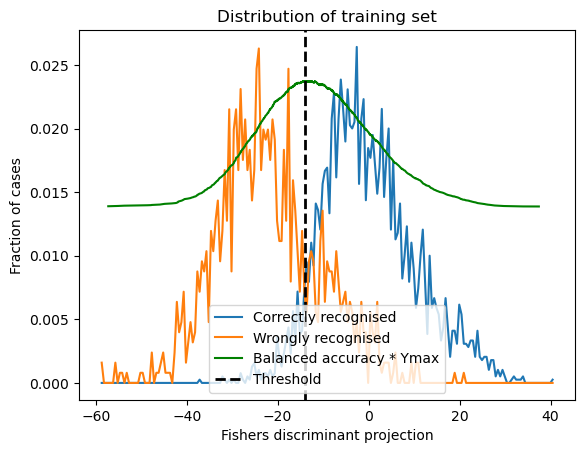

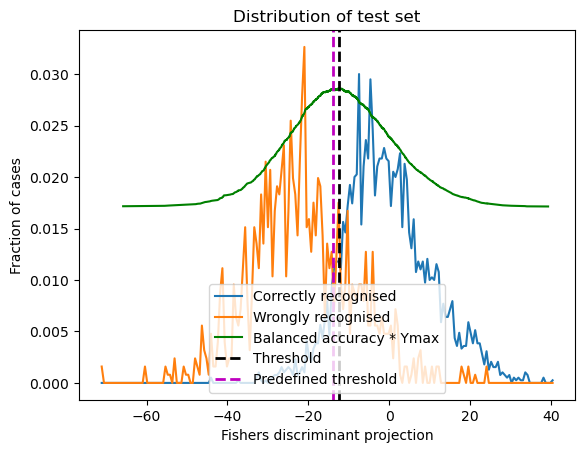

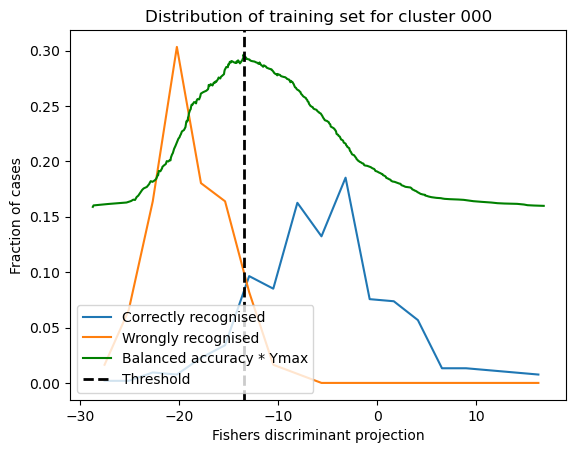

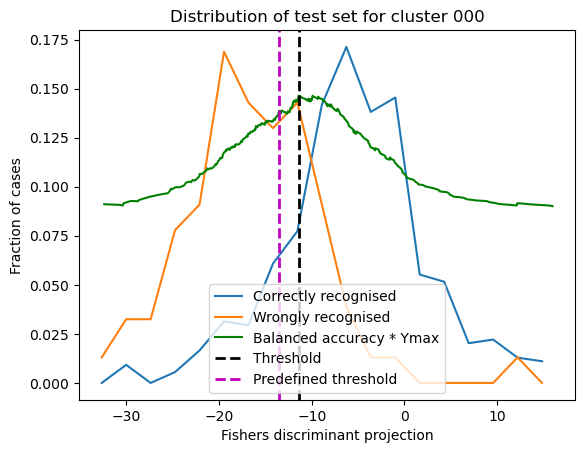

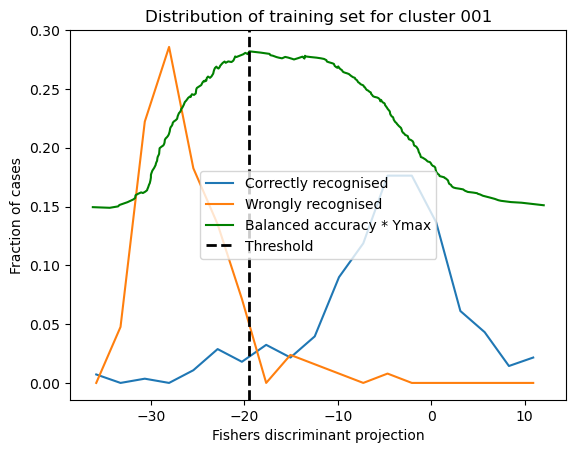

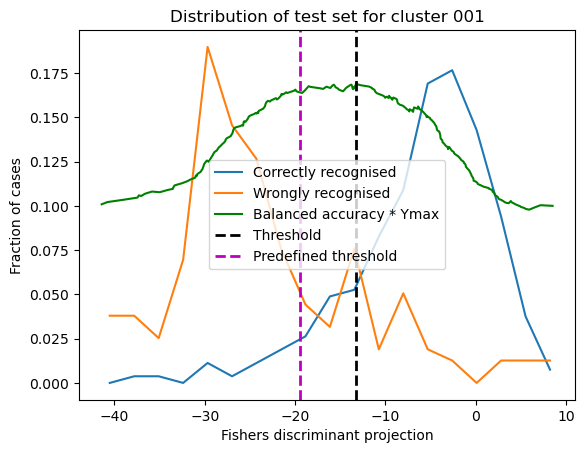

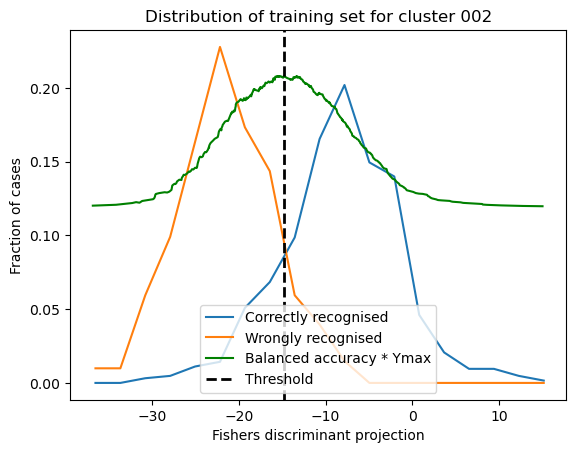

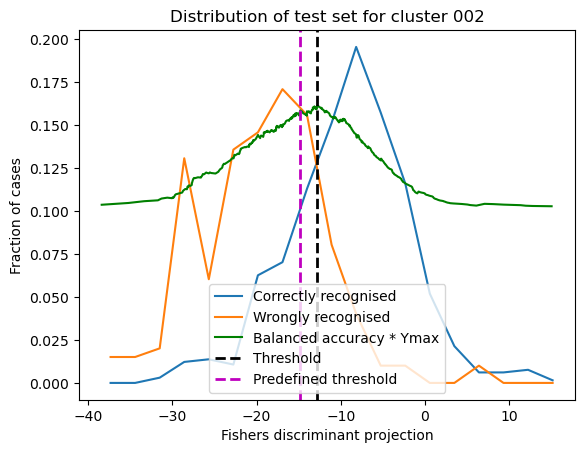

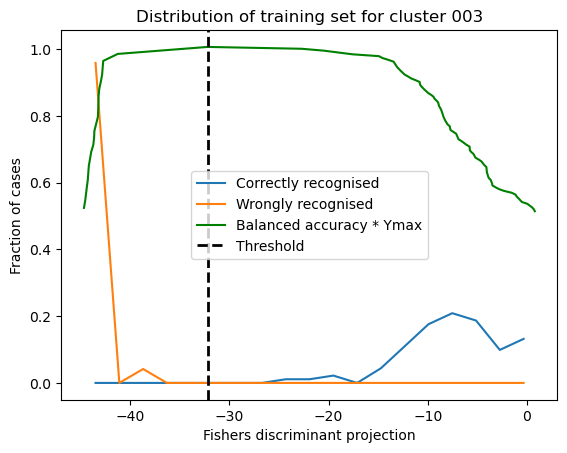

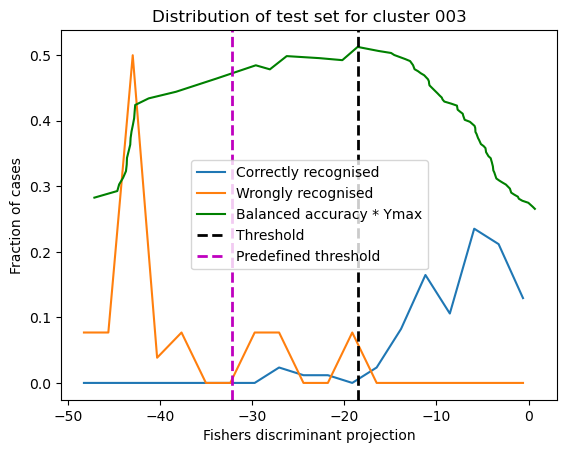

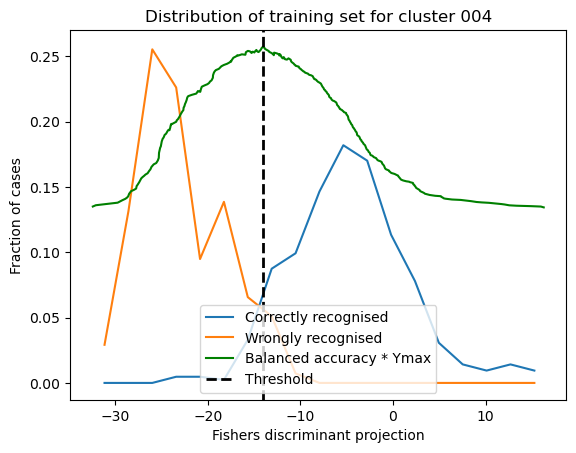

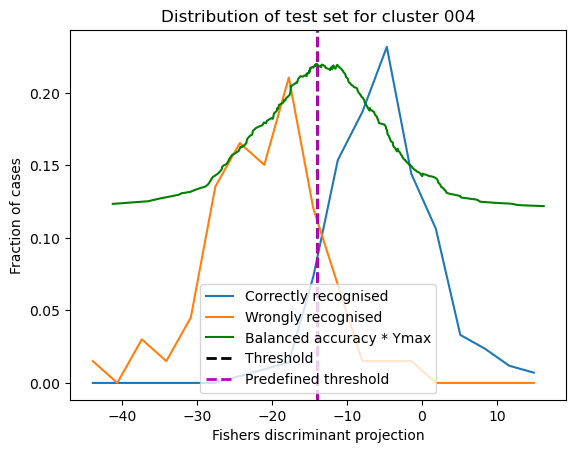

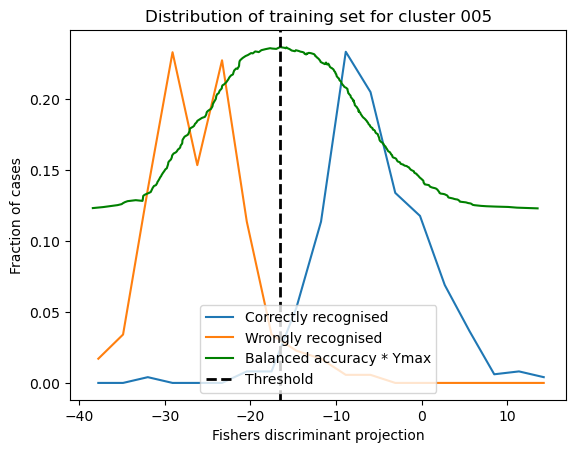

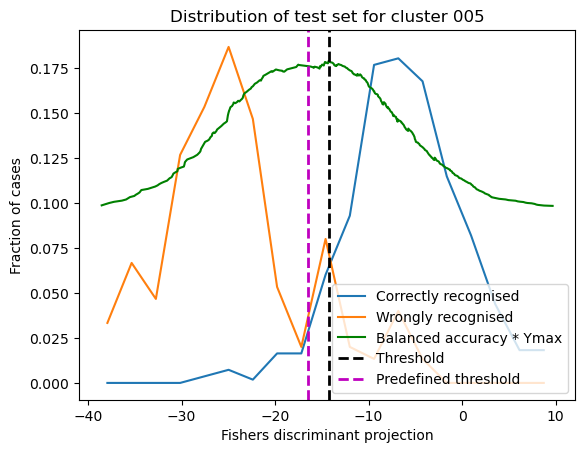

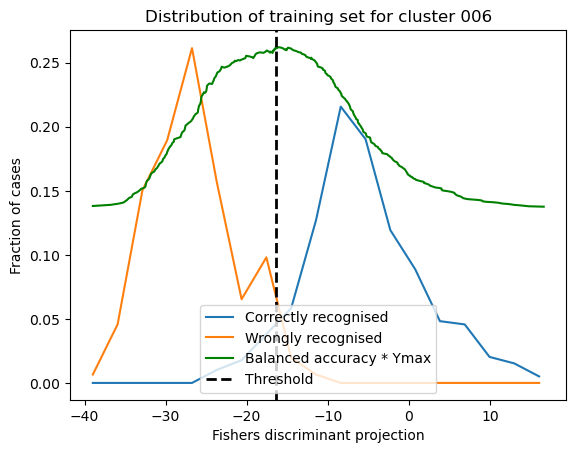

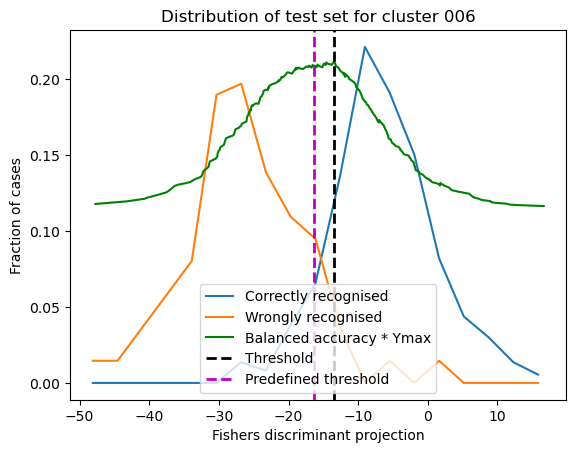

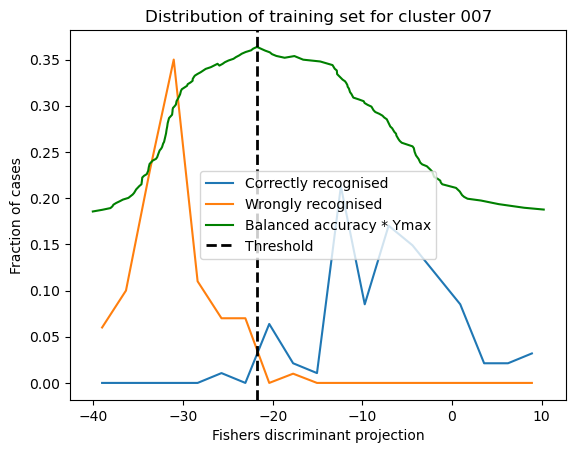

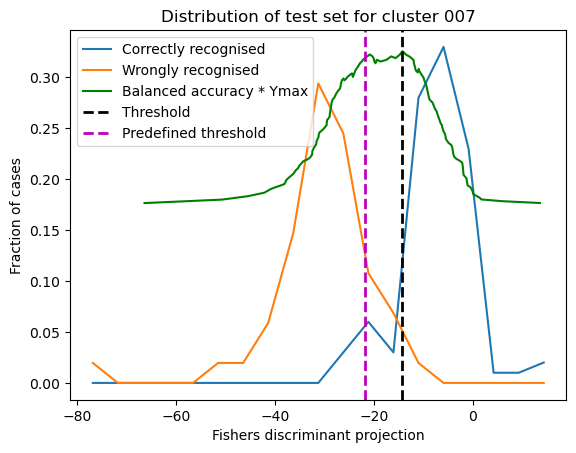

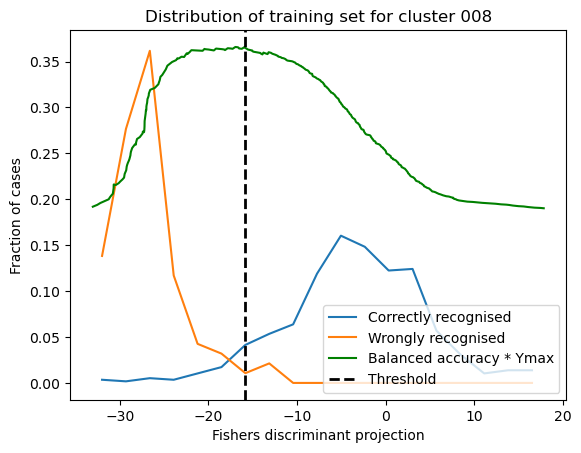

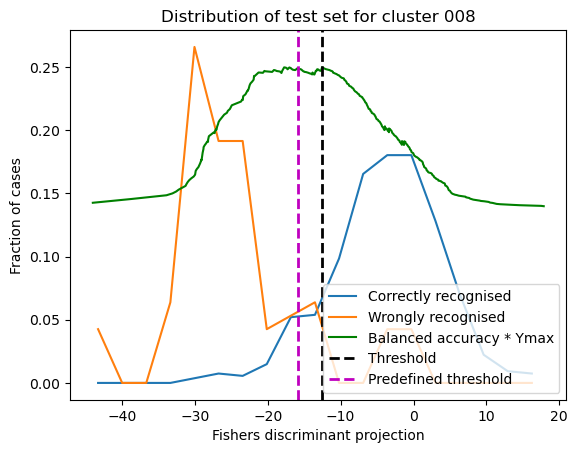

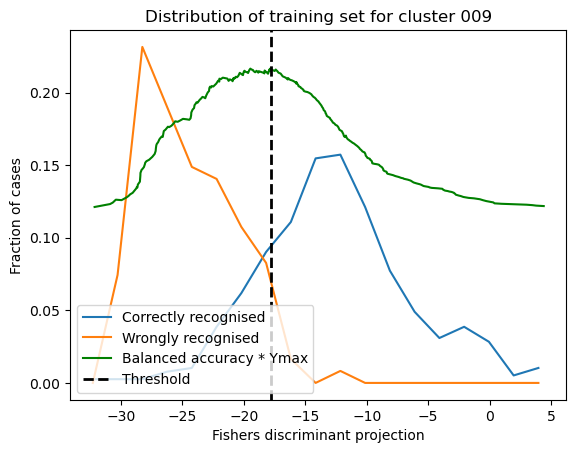

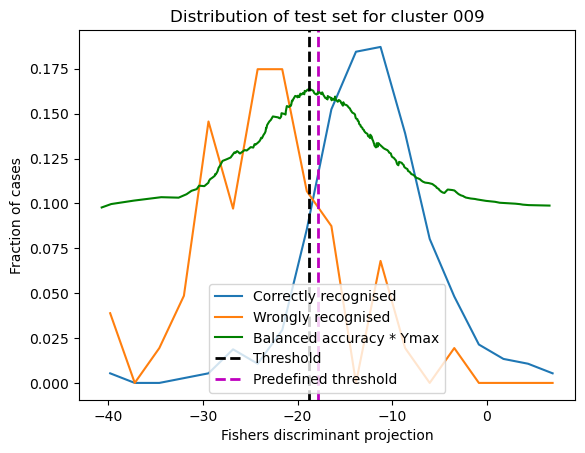

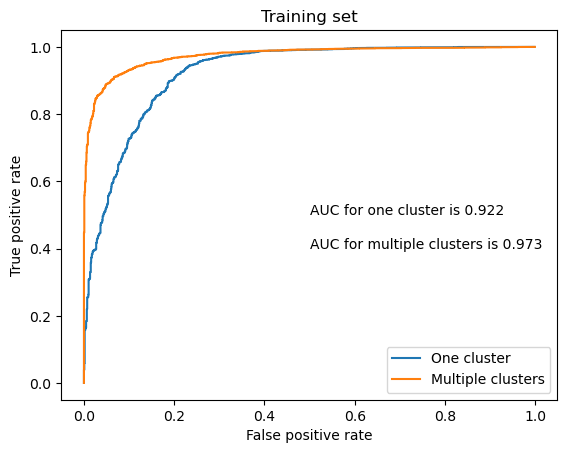

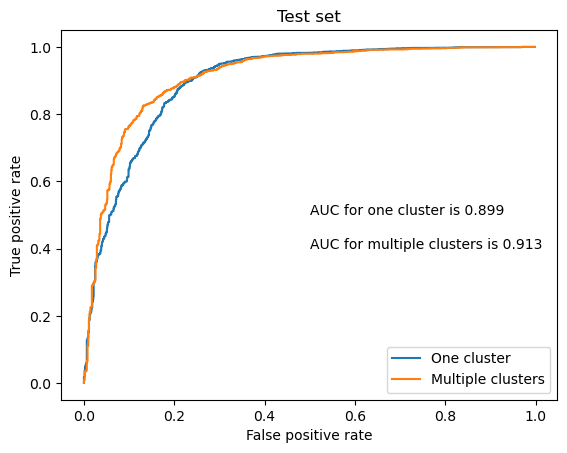

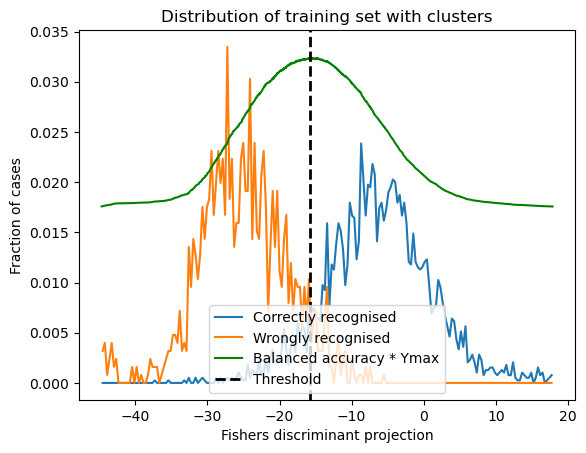

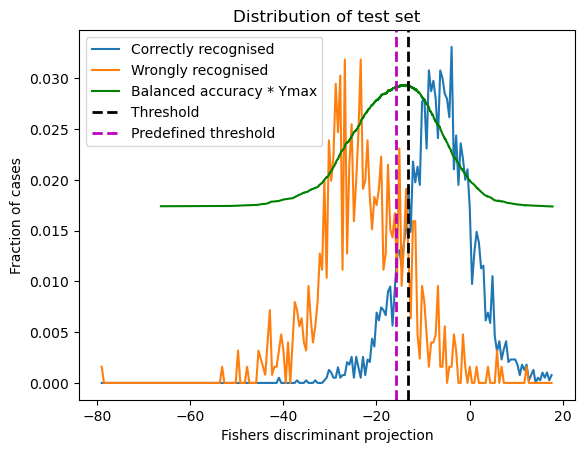

In [254]:
statsErrorCorrector(result)